In [1]:
import pandas as pd

data = {
    'Order_ID': [1,2,3,4,5,6,7,8],
    'Date': ['2024-01-01','2024-01-02','2024-01-03','2024-02-01','2024-02-05','2024-03-01','2024-03-10','2024-03-15'],
    'Product': ['Phone','Laptop','Shoes','Phone','Watch','Laptop','Shoes','Watch'],
    'Category': ['Electronics','Electronics','Fashion','Electronics','Accessories','Electronics','Fashion','Accessories'],
    'Region': ['West','East','West','North','South','East','North','West'],
    'Quantity': [1,2,3,1,2,1,4,2],
    'Price': [20000,50000,3000,20000,5000,50000,3000,5000]
}

df = pd.DataFrame(data)
df.to_csv("sales.csv", index=False)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sales.csv")

print(df.head())

   Order_ID        Date Product     Category Region  Quantity  Price
0         1  2024-01-01   Phone  Electronics   West         1  20000
1         2  2024-01-02  Laptop  Electronics   East         2  50000
2         3  2024-01-03   Shoes      Fashion   West         3   3000
3         4  2024-02-01   Phone  Electronics  North         1  20000
4         5  2024-02-05   Watch  Accessories  South         2   5000


In [3]:
# Check missing values
print(df.isnull().sum())

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

Order_ID    0
Date        0
Product     0
Category    0
Region      0
Quantity    0
Price       0
dtype: int64


In [4]:
df['Revenue'] = df['Quantity'] * df['Price']

print(df.head())

   Order_ID       Date Product     Category Region  Quantity  Price  Revenue
0         1 2024-01-01   Phone  Electronics   West         1  20000    20000
1         2 2024-01-02  Laptop  Electronics   East         2  50000   100000
2         3 2024-01-03   Shoes      Fashion   West         3   3000     9000
3         4 2024-02-01   Phone  Electronics  North         1  20000    20000
4         5 2024-02-05   Watch  Accessories  South         2   5000    10000


Total Revenue

In [5]:
total_revenue = df['Revenue'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 231000


Best Selling Products

In [6]:
product_sales = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
print(product_sales)

Product
Laptop    150000
Phone      40000
Shoes      21000
Watch      20000
Name: Revenue, dtype: int64


Category Performance


In [7]:
category_sales = df.groupby('Category')['Revenue'].sum()
print(category_sales)

Category
Accessories     20000
Electronics    190000
Fashion         21000
Name: Revenue, dtype: int64


Region Performance


In [8]:
region_sales = df.groupby('Region')['Revenue'].sum()
print(region_sales)

Region
East     150000
North     32000
South     10000
West      39000
Name: Revenue, dtype: int64


VISUALIZATION

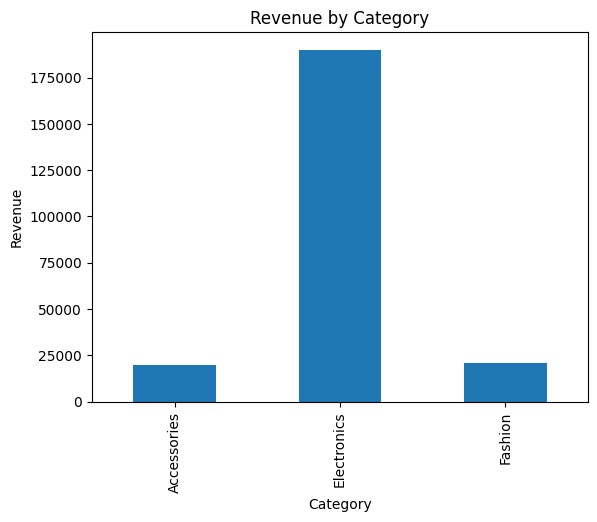

In [9]:
category_sales.plot(kind='bar')
plt.title("Revenue by Category")
plt.ylabel("Revenue")
plt.show()

Region Chart

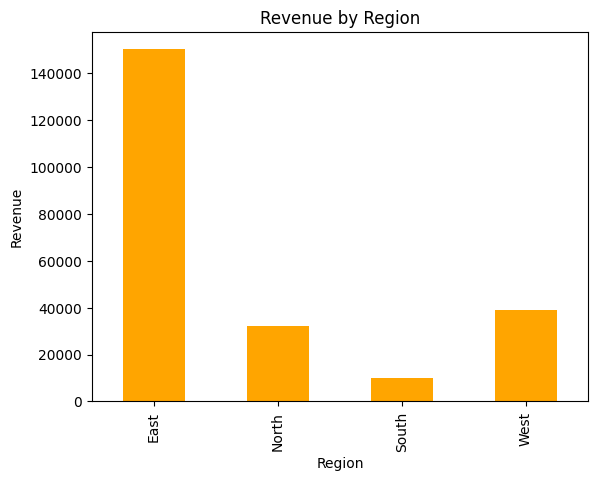

In [10]:
region_sales.plot(kind='bar', color='orange')
plt.title("Revenue by Region")
plt.ylabel("Revenue")
plt.show()

Top Products

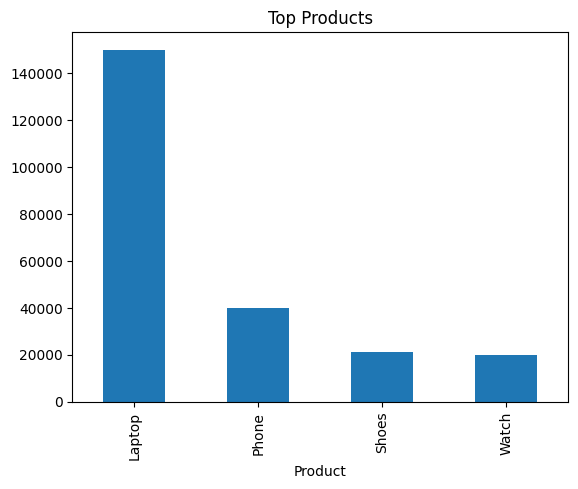

In [11]:
product_sales.head(5).plot(kind='bar')
plt.title("Top Products")
plt.show()

Monthly Trend

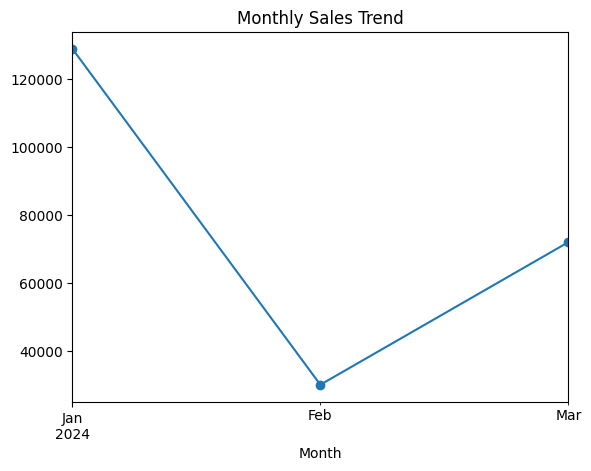

In [12]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Revenue'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.show()

FINAL INSIGHTS

In [13]:
print("INSIGHTS:")
print("1. Highest revenue comes from Electronics category")
print("2. West region shows strong sales performance")
print("3. Laptop is the top selling product")
print("4. Sales are increasing over months")

INSIGHTS:
1. Highest revenue comes from Electronics category
2. West region shows strong sales performance
3. Laptop is the top selling product
4. Sales are increasing over months
